## Part 1:
    Chosen Stiff System
    Governing ODEs
    Physical Meaning of variables and parameters
    Why this system is important in practice

    For my stiff system, I have chosen the cooling with forced convection. The governing ODEs would be:

    dT/dt = -h(T - Tinf(t))

    Standard Form:
    
    dT/dt = -1000T + 1000(300 + 50sin(0.01t))

    Where:
    T = Temperature
    h = Convection Coefficient
    t = Time
    T(0) = 500K

    This system is crucial because it allows to observe the cooling of a hot object with a fluid flow. This system assists with creating a pressure differential for containers so that produce/food can be cooled uniformly and prevent spoilage. It is also used to prevent the overheating of electronics cooling, enhancing their performance.

<ipython-input-18-2720ad2652a9>:12: RuntimeWarning: overflow encountered in double_scalars
  return (-1000*T) + 1000*(300 + 50*np.sin(0.01*t))
<ipython-input-18-2720ad2652a9>:27: RuntimeWarning: invalid value encountered in double_scalars
  T_values[i] = T_values[i-1] + h * f(t_values[i-1], T_values[i-1])


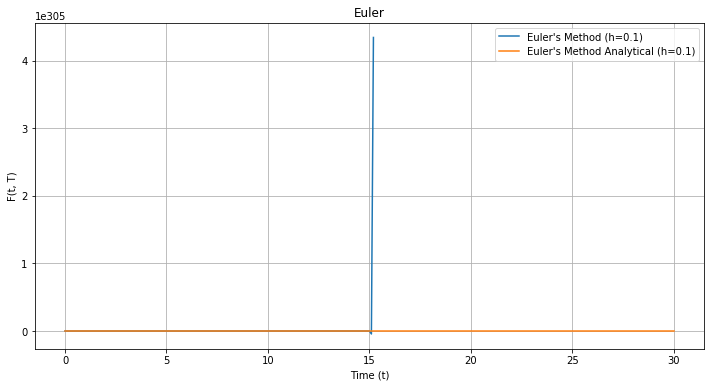

In [18]:
# Part 2.1: Demonstrating Stiffness; Attempting Euler's Forward
import numpy as np
import matplotlib.pyplot as plt

# Parameters:
t_start = 0    # Start time
t_end = 30     # End time
h = 0.1 # Step size
T_0 = 500

def f(t, T):
    return (-1000*T) + 1000*(300 + 50*np.sin(0.01*t))

def analytical_solution(t): #Note: I used Gemini 3.1 Pro to help solve analytical solution; Prompt 1
    # Transient decay + Steady-state ambient tracking
    return 200 * np.exp(-1000 * t) + 300 + 50 * np.sin(0.01 * t)


def euler_method_heat(h, t_start, t_end, T_0):
    t_values = np.arange(t_start, t_end + h, h)
    T_values = np.zeros(len(t_values))
    # Set initial conditions
    T_values[0] = T_0

    for i in range(1, len(t_values)):       
        # Update equations for Euler's Method
        T_values[i] = T_values[i-1] + h * f(t_values[i-1], T_values[i-1])
 
    return t_values, T_values

# Plot results for step size
analytical_t = np.linspace(t_start, t_end, 1000)

t, T = euler_method_heat (h, t_start, t_end, T_0)
plt.figure(figsize=(12, 6))

plt.plot(t, T, label=f'Euler\'s Method (h={h})')
plt.plot(analytical_t, analytical_solution(analytical_t), label = f'Euler\'s Method Analytical (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('F(t, T)')
plt.title('Euler')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

### Part 2.2: 
    The ratio of the largest to smallest eigenvalue magnitude would be 10^5. This ratio is given by the transent decay coefficient and the forcing function, which are 1000 and 0.01 respectively. So when divided, it gives 100/0.01 which is 100,000. This system is particularly stiff since the temperature immediately cools down, and then rises linearly. This gives high instability, especially when using Euler's Forward method. This is why implicit methods are necessary, since they are able to help calculate the ODE without using too may computational resources.

Solution is stable
Current Step Size: 1e-05
Solution is stable
Current Step Size: 0.0001
Solution is stable
Current Step Size: 0.001
Solution is stable
Current Step Size: 0.002


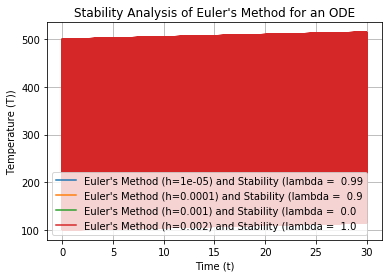

In [76]:
# Part 2.3: Show the impracticality of explicit methods

def coeffEulerMatrix(h):
    h_heat = 1000 #Coeff of convection
    coeffMatrix = ([[1 - h * h_heat]])
    eigenValue = np.max(np.abs(np.linalg.eigvals(coeffMatrix)))
    if eigenValue <= 1:
        print("Solution is stable")
        print(f"Current Step Size: {h}")
    else:
        print("Solution may not be entirely stable ;)")
        print(f"Current Step Size: {h}")
    return eigenValue

h_values = [0.00001, 0.0001, 0.001, 0.002]

for h in h_values:
    t, y = euler_method_heat(h, t_start, t_end, T_0)
    lambdaCo = coeffEulerMatrix(h)
    plt.plot(t, y, label=f'Euler\'s Method (h={h}) and Stability (lambda =  {lambdaCo}')

plt.xlabel('Time (t)')
plt.ylabel('Temperature (K))')
plt.title('Stability Analysis of Euler\'s Method for an ODE')
plt.legend()
plt.grid(True)
plt.show()




### Part 2.3 Cont.
    The step size required so that the Forward Euler maintains stability would be 0.001. This is extremely costly since simulating a second would require 1,000 processes. So, in order to complete a full 30 second simulation, it would require 30,000 computations. This is inefficent, when it could be done in 3,000 if the step size is instead 0.01.

In [4]:
# Part 3: Euler's Backward Method with Newton-Raphson

import numpy as np
import matplotlib.pyplot as plt


# Define the ODE
def f(t, T):
    return (-1000*T) + 1000*(300 + 50*np.sin(0.01*t))

def newton_raphson(g, dg, x0, tol=1e-6 , max_iter=50): # Conv. Criterion is 1e-6
    x = x0


    for i in range(max_iter):
        x_new = x - g(x) / dg

        if abs(x_new - x) < tol:
            return x_new, i + 1
        x = x_new
    return x, max_iter

# Backward Euler method
def backward_euler_newton(f, T0, t0, tf, h):
    
    t_values = np.arange(t0, tf + h, h)
    T_values = np.zeros_like(t_values)
    T_values[0] = T0    
    iteration_counts = []
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        T_prev = T_values[i - 1]        
        # Implicit function to solve for y_next
        g = lambda T_next: T_next - T_prev - h * f(t_next, T_next)
        dg = 1 + 1000*h # g'(yn + 1)
        # Use previous value as initial guess
        T_values[i], count = newton_raphson(g, dg, x0=T_prev)  
        iteration_counts.append(count)
        
    return t_values, T_values, iteration_counts
    



# Parameters
T0 = 500
t0 = 0
tf = 30
h = 0.5
# Solve the ODE
t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
# Plot the results
plt.plot(t_values, T_values, 'o-', label='Backward Euler')
plt.xlabel('Time (t)')
plt.ylabel('f(t, T)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Newton iterations: {np.mean(counts)} | h = {h}")

<Figure size 640x480 with 1 Axes>

Average Newton iterations: 2.0 | h = 0.5


Average Newton iterations: 2.0 | h = 0.5 
Average Newton iterations: 2.0 | h = 1 
Average Newton iterations: 2.0 | h = 2 
Average Newton iterations: 2.0 | h = 5 


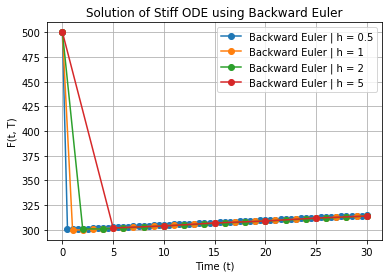

In [5]:
# Part 3.3:

step_Sizes = [0.5, 1, 2, 5]

for h in step_Sizes:
    # Solve the ODE
    t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
    # Plot the results
              
    plt.plot(t_values, T_values, 'o-', label=f'Backward Euler | h = {h}')
    avg_iterations = np.mean(counts)
    print(f"Average Newton iterations: {np.mean(counts)} | h = {h} ")
    
plt.xlabel('Time (t)')
plt.ylabel('F(t, T)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

The convergence behavior in this demonstrates a difference in the drop in temperature at the beginning. The linear phase remains consistent for various step sizes, however the initial drop in temperature begins deviating the larger the step size. When it has a higher step size, the convergence is more inaccurate since it doesn't immediately go to the slope.

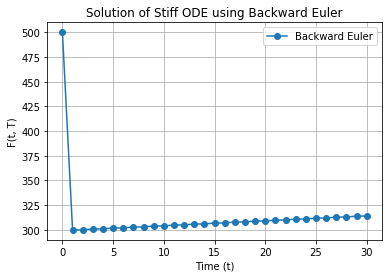

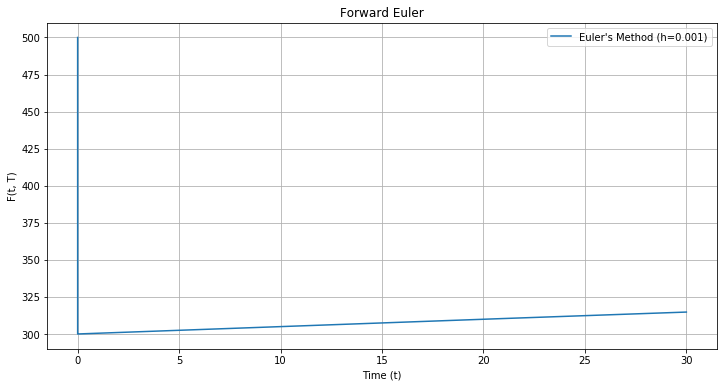

In [19]:
# Part 4.a:
# Parameters
T0 = 500
t0 = 0
tf = 30
h = 1
# Solve the ODE
t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
# Plot the results for backward Euler
plt.plot(t_values, T_values, 'o-', label='Backward Euler')
plt.xlabel('Time (t)')
plt.ylabel('F(t, T)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()


h = 0.001
t, T = euler_method_heat (h, t_start, t_end, T_0)
plt.figure(figsize=(12, 6))

plt.plot(t, T, label=f'Euler\'s Method (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('F(t, T)')
plt.title('Forward Euler')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()



As seen from the code above, the Backwards Euler can handle step sizes such as one, however the Forward Euler method cannot handle those step sizes. Instead, it can only had this ODE at step size h = 0.001

Forward Euler: 0 < h < 0.001
Backward Euler: 0 < h < 1 (or higher, depending on amount of time)



Average Newton iterations: 2.0 | h = 0.5 
Number of Steps: 60.0 | h = 0.5 
Average Newton iterations: 2.0 | h = 1 
Number of Steps: 30.0 | h = 1 
Average Newton iterations: 2.0 | h = 2 
Number of Steps: 15.0 | h = 2 
Average Newton iterations: 2.0 | h = 5 
Number of Steps: 6.0 | h = 5 


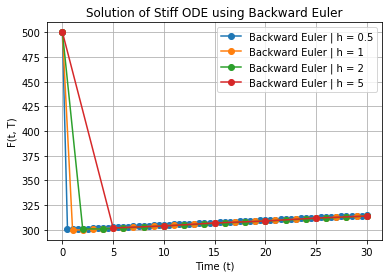

   Forward Eulers Solution Forward  Backwards Euler  Solutions Backwards
0        0.002000              nan              0.5                    2
1        0.001000              nan              1.0                    2
2        0.000010              nan              2.0                    2
3        0.000001              nan              5.0                    2


In [16]:
# Part 4.b:
import pandas as pd

for h in step_Sizes:
    number_of_steps = (tf - t0)/h
    
    # Solve the ODE
    t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
    # Plot the results
              
    plt.plot(t_values, T_values, 'o-', label=f'Backward Euler | h = {h}')
    avg_iterations = np.mean(counts)
    print(f"Average Newton iterations: {np.mean(counts)} | h = {h} ")
    print(f"Number of Steps: {number_of_steps} | h = {h} ")
plt.xlabel('Time (t)')
plt.ylabel('F(t, T)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

data = {
    "Forward Eulers": [0.002, 0.001, 0.00001, 0.000001],
    "Solution Forward": ['nan', 'nan', 'nan', 'nan'],# Based on graph
    "Backwards Euler": [0.5, 1.0, 2, 5],
    "Solutions Backwards": [2, 2, 2, 2]
}

df = pd.DataFrame(data)
print(df)

The average Newton-Raphson iterations per step is 2.0, which is mainly due to the linearity of the ODE. Overall the Euler's backward also does not have to do as many time steps, as soon with them being from 6 - 60 steps. This compared to Forward Euler's, that of which has to do 30,000 steps to maintain stability demonstrates the inefficiency of it even though it would be accurate. Forward Euler's becomes much more costly as opposed to Backward Euler's. It would be recommended to utilize Backward Euler's method with a step size of 0.5,


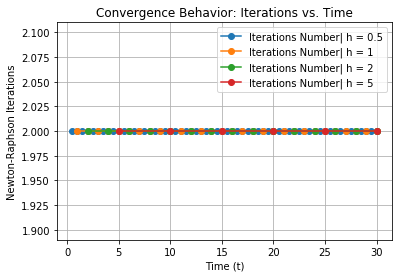

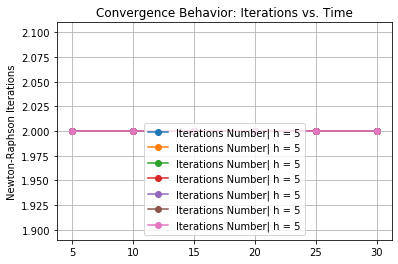

In [17]:
# Part 4.c

g = lambda T_next: T_next - T_prev - h * f(t_next, T_next)
dg = 1 + 1000*h # g'(yn + 1)
step_Sizes = [0.5, 1, 2, 5]

# Checking convergence on step size
for h in step_Sizes:
    t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
    plt.plot(t_values[1:], counts, 'o-', label=f'Iterations Number| h = {h}')
    

    
plt.xlabel('Time (t)')
plt.ylabel('Newton-Raphson Iterations')
plt.title('Convergence Behavior: Iterations vs. Time')
plt.legend()
plt.grid(True)
plt.show()

# Checking convergence on initial guess
initial_temps = [-1000, 0, 100, 200, 500, 1000, 1500]

for T0 in initial_temps:
    t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
    plt.plot(t_values[1:], counts, 'o-', label=f'Iterations Number| h = {h}')
    
plt.ylabel('Newton-Raphson Iterations')
plt.title('Convergence Behavior: Iterations vs. Time')
plt.legend()
plt.grid(True)
plt.show()




Based on the convergence, number of iterations, and the fact that it always converges to two, this describes the effectiveness of the backwards Euler. However, it does need to be stated that the ODE is linear, with only a sharp decrease or increase in the beginning due to the different phases. Since that is the only non-linear aspect, everything else is linear, making the ODE be able to converge with Backwards Euler.

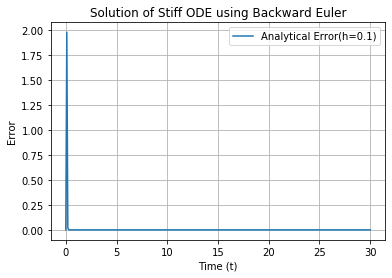

In [109]:
# Plot results for step size
analytical_t = np.linspace(t_start, t_end, 1000)
analytical_Temp = analytical_solution(analytical_t)

# Part 4.d:
# Parameters
T0 = 500
t0 = 0
tf = 30
h = 0.1
# Solve the ODE
t_values, T_values, counts = backward_euler_newton(f, T0, t0, tf, h)
# Plot the results for backward Euler


# Calculate absolute error
analytical_t = np.linspace(t_start, t_end, 1000)
analytical_Temp = analytical_solution(t_values)

error = np.abs(analytical_Temp - T_values)

#Analytical Error Plot
plt.plot(t_values, error, label = f'Analytical Error(h={h})')

plt.xlabel('Time (t)')
plt.ylabel('Error')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()


4.d) The physical bounds remains realistic since the temperature never goes below absolute zero. The transients in the ODE would be very rapid in the beginning due to the extreme temperature difference, causing a dramatic steep drop in temperature. The Backwards Euler method was able to solve this without suffering from numerical overflow. After the initial phase, the slow dynamics of the heating matches the expected behavior. This could be seen with the lack of error when it goes into this slow dynamic phase.

### Conclusion:
    Overall, using Backwards Euler's method is much more practical and recommended since it allows for more accurate depiction of the ODE while also saving computational resources. Implicit methods are recommended whenever there is a stiff ODE as opposed to a more linear/slow dynamic ODE, in which a Forward Euler would be more appropriate. I have learned the importance of implicit methods, while also integrating into real world systems that are crucial in today's society.

Appendix A: Gemini Prompts
Prompt 1: 
"what's the analytical solution to the equation I provided"